## Step 1: Settings and imports

In [7]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
SIZES = [2500, 5000]      
EPOCHS = [50, 100]        
LEARNING_RATE = 0.01   
BATCH_SIZE = 64
OUTPUT_DIR = "output"     
NOISE = 0.15            

os.makedirs(OUTPUT_DIR, exist_ok=True)


def set_seed():
    """Make every run give the same result."""
    np.random.seed(SEED)
    tf.random.set_seed(SEED)


## Step 2: Load MNIST

In [8]:
(x_a, y_a), (x_b, y_b) = tf.keras.datasets.mnist.load_data()
X = np.concatenate([x_a, x_b]).reshape(-1, 784) / 255.0   # flatten 28x28 -> 784, scale to 0..1
Y = np.concatenate([y_a, y_b])
print("Total images:", len(X))

Total images: 70000


## Step 3: Helper functions

Each function does one small job, so `run_experiment` is easy to read.

In [9]:
def build_autoencoder():
    """784 -> 512 -> 256 (bottleneck) -> 512 -> 784"""
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu"),      # encoder
        layers.Dense(256, activation="relu"),      # bottleneck
        layers.Dense(512, activation="relu"),      # decoder
        layers.Dense(784, activation="sigmoid"),   # output: 784 pixels
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE), loss="mse", metrics=["mse", "mae"])
    return model


def build_classifier():
    """Small digit reader, used only to score the reconstructed images."""
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def split_data(size):
    """Pick `size` random images, then split 70% train / 20% test / 10% validation."""
    idx = np.random.RandomState(SEED).permutation(len(X))[:size]
    x, y = X[idx], Y[idx]
    x_train, x_rest, y_train, y_rest = train_test_split(x, y, train_size=0.70, random_state=SEED)
    x_test, x_val, y_test, y_val = train_test_split(x_rest, y_rest, train_size=2 / 3, random_state=SEED)
    return x_train, y_train, x_val, x_test, y_test


def add_noise(images):
    """Add Gaussian noise and keep pixels in 0..1."""
    noise = NOISE * np.random.RandomState(SEED).normal(size=images.shape)
    return np.clip(images + noise, 0, 1)


def plot_loss(history, title, extra=None, path=None):
    epochs_range = range(1, len(history.history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Subplot 1: Training Loss vs Validation Loss (MSE)
    axes[0].plot(epochs_range, history.history["loss"], label="Training Loss", color="#1f77b4", lw=2)
    axes[0].plot(epochs_range, history.history["val_loss"], label="Validation Loss", color="#ff7f0e", lw=2)
    if extra and "test_mse" in extra and len(extra["test_mse"]) == len(epochs_range):
        axes[0].plot(epochs_range, extra["test_mse"], label="Test MSE (noisy)", color="#2ca02c", linestyle="--", lw=2)
    axes[0].set_title("Training Loss vs Validation Loss", fontsize=11, fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss (MSE)")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    axes[0].legend()

    # Subplot 2: MAE curves (Train MAE, Val MAE)
    if "mae" in history.history:
        axes[1].plot(epochs_range, history.history["mae"], label="Train MAE", color="#1f77b4", lw=2)
        axes[1].plot(epochs_range, history.history["val_mae"], label="Val MAE", color="#ff7f0e", lw=2)
        axes[1].set_title("Mean Absolute Error (MAE)", fontsize=11, fontweight="bold")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].grid(True, linestyle=":", alpha=0.6)
        axes[1].legend()

    fig.suptitle(title, fontsize=12, y=1.02)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_examples(original, noisy, result, n=6, path=None):
    fig, axes = plt.subplots(n, 3, figsize=(4.5, 1.4 * n))
    columns = [("Original", original), ("Test (noisy)", noisy), ("Result", result)]
    for row in range(n):
        for col, (name, images) in enumerate(columns):
            axes[row, col].imshow(images[row].reshape(28, 28), cmap="gray")
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(name, fontsize=10, fontweight="bold")
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_ten_digits(original, noisy, result, y_true, y_pred, path):
    """Save one example of each digit 0-9: Original | Test (noisy) | Result (reconstruction)."""
    fig, axes = plt.subplots(10, 3, figsize=(4, 14))
    for digit in range(10):
        i = int(np.where(y_true == digit)[0][0])          # first test image of this digit
        panels = [
            (original[i], "Original" if digit == 0 else "", "black"),
            (noisy[i], "Test" if digit == 0 else "", "black"),
            (result[i], "Result" if digit == 0 else "", "black")
        ]
        for col, (img, title, color) in enumerate(panels):
            axes[digit, col].imshow(img.reshape(28, 28), cmap="gray")
            axes[digit, col].axis("off")
            if title:
                axes[digit, col].set_title(title, fontsize=10, color=color)
    fig.suptitle("Result of 10 digits", y=0.995)
    fig.tight_layout()
    fig.savefig(path, dpi=100)
    plt.close(fig)


def plot_confusion(y_true, y_pred, path=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot(cmap="Blues", ax=ax)
    ax.set_title("Confusion matrix (reconstructed test digits)", fontsize=10)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_experiment_dashboard(history, extra, x_test, x_test_noisy, result, y_test, y_pred, size, epochs, path):
    """Save a consolidated composite dashboard for the experiment:
    - Left: 10 Digits Reconstructions (Original | Test | Result) without 'Read as :'
    - Right Top: Training Loss vs Validation Loss & MAE curves
    - Right Bottom: Confusion Matrix on reconstructed test digits
    """
    fig = plt.figure(figsize=(15, 10))
    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]
    test_mse = float(np.mean((result - x_test) ** 2))
    acc = float(np.mean(y_pred == y_test))

    fig.suptitle(
        f"Experiment: Size = {size}, Epochs = {epochs} | "
        f"Training Loss: {train_loss:.4f} | Validation Loss: {val_loss:.4f} | Test MSE: {test_mse:.4f} | Accuracy: {acc:.2%}",
        fontsize=13, fontweight="bold", y=0.98
    )

    outer_gs = gridspec.GridSpec(1, 2, width_ratios=[1.0, 1.2], wspace=0.25)

    # Left: 10 rows x 3 columns for digits 0-9
    left_gs = gridspec.GridSpecFromSubplotSpec(10, 3, subplot_spec=outer_gs[0], hspace=0.08, wspace=0.08)
    for digit in range(10):
        idx = int(np.where(y_test == digit)[0][0])
        panels = [
            (x_test[idx], "Original" if digit == 0 else ""),
            (x_test_noisy[idx], "Test" if digit == 0 else ""),
            (result[idx], "Result" if digit == 0 else "")
        ]
        for col, (im, col_title) in enumerate(panels):
            ax = fig.add_subplot(left_gs[digit, col])
            ax.imshow(im.reshape(28, 28), cmap="gray")
            ax.axis("off")
            if col_title:
                ax.set_title(col_title, fontsize=10, fontweight="bold", pad=3)

    # Right: Loss/MAE Curves & Confusion Matrix
    right_gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_gs[1], height_ratios=[1, 1.2], hspace=0.35, wspace=0.25)
    epochs_range = range(1, len(history.history["loss"]) + 1)

    # Top-Left: Training Loss vs Validation Loss
    ax_loss = fig.add_subplot(right_gs[0, 0])
    ax_loss.plot(epochs_range, history.history["loss"], label="Training Loss", color="#1f77b4", lw=2)
    ax_loss.plot(epochs_range, history.history["val_loss"], label="Validation Loss", color="#ff7f0e", lw=2)
    if "test_mse" in extra and len(extra["test_mse"]) == len(epochs_range):
        ax_loss.plot(epochs_range, extra["test_mse"], label="Test MSE (noisy)", color="#2ca02c", linestyle="--", lw=2)
    ax_loss.set_title("Training Loss vs Validation Loss", fontsize=10, fontweight="bold")
    ax_loss.set_xlabel("Epoch", fontsize=8)
    ax_loss.set_ylabel("Loss (MSE)", fontsize=8)
    ax_loss.grid(True, linestyle=":", alpha=0.6)
    ax_loss.legend(fontsize=8)

    # Top-Right: MAE
    ax_mae = fig.add_subplot(right_gs[0, 1])
    if "mae" in history.history:
        ax_mae.plot(epochs_range, history.history["mae"], label="Train MAE", color="#1f77b4", lw=2)
        ax_mae.plot(epochs_range, history.history["val_mae"], label="Val MAE", color="#ff7f0e", lw=2)
        ax_mae.set_title("MAE Curves", fontsize=10, fontweight="bold")
        ax_mae.set_xlabel("Epoch", fontsize=8)
        ax_mae.set_ylabel("MAE", fontsize=8)
        ax_mae.grid(True, linestyle=":", alpha=0.6)
        ax_mae.legend(fontsize=8)

    # Bottom: Confusion Matrix
    ax_cm = fig.add_subplot(right_gs[1, :])
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap="Blues", ax=ax_cm, colorbar=False)
    ax_cm.set_title("Confusion Matrix (Reconstructed Test Digits)", fontsize=10, fontweight="bold")

    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## Step 4: One experiment

split -> add noise to test set -> train -> reconstruct -> plot -> return numbers

In [10]:
def run_experiment(size, epochs):
    print(f"===== Size = {size}, Epochs = {epochs} =====")
    set_seed()

    x_train, y_train, x_val, x_test, y_test = split_data(size)
    x_test_noisy = add_noise(x_test)

    # Train: input = output = clean image
    model = build_autoencoder()
    extra = {"test_mse": [], "time": []}

    class EpochLogger(tf.keras.callbacks.Callback):
        def on_epoch_begin(self, epoch, logs=None):
            self.start = time.time()

        def on_epoch_end(self, epoch, logs=None):
            extra["time"].append(time.time() - self.start)
            pred = self.model(x_test_noisy, training=False).numpy()
            extra["test_mse"].append(float(np.mean((pred - x_test) ** 2)))

    history = model.fit(x_train, x_train, validation_data=(x_val, x_val),
                        epochs=epochs, batch_size=BATCH_SIZE, verbose=0,
                        callbacks=[EpochLogger()])

    # Save the loss and metrics of every epoch to a CSV file
    train_mse = history.history.get("mse", history.history["loss"])
    val_mse = history.history.get("val_mse", history.history["val_loss"])
    epoch_table = pd.DataFrame({
        "Epoch": range(1, epochs + 1),
        "Train Loss": history.history["loss"],
        "Val Loss": history.history["val_loss"],
        "Train MSE": train_mse,
        "Val MSE": val_mse,
        "Train MAE": history.history["mae"],
        "Val MAE": history.history["val_mae"],
        "Test MSE": extra["test_mse"],
        "Loss Gap (Val-Train)": np.array(history.history["val_loss"]) - np.array(history.history["loss"]),
        "Epoch Time (s)": extra["time"],
    })
    epoch_table.to_csv(f"{OUTPUT_DIR}/epochs_size{size}_epochs{epochs}.csv", index=False)

    # Reconstruct the noisy test images and compare with the clean originals
    result = model.predict(x_test_noisy, verbose=0)
    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]
    train_mae = history.history["mae"][-1]
    val_mae = history.history["val_mae"][-1]
    test_mse = float(np.mean((result - x_test) ** 2))

    # Classify the reconstructions to build the confusion matrix
    classifier = build_classifier()
    classifier.fit(x_train, y_train, epochs=10, verbose=0)
    y_pred = classifier.predict(result, verbose=0).argmax(axis=1)
    accuracy = float(np.mean(y_pred == y_test))

    print(f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | "
          f"Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f} | "
          f"Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} | "
          f"Test MSE: {test_mse:.4f} | Digit accuracy: {accuracy:.2%}")

    # 1. Save consolidated dashboard grouping all experiment plots
    save_experiment_dashboard(
        history, extra, x_test, x_test_noisy, result, y_test, y_pred,
        size=size, epochs=epochs,
        path=f"{OUTPUT_DIR}/result_grouped_size{size}_epochs{epochs}.png"
    )

    # 2. Save standalone Loss & MSE plot showing Training Loss and Validation Loss clearly
    plot_loss(
        history,
        title=f"Training Loss vs Validation Loss (size={size}, epochs={epochs})",
        extra=extra,
        path=f"{OUTPUT_DIR}/graph_loss_size{size}_epochs{epochs}.png"
    )

    return {
        "Size": size,
        "Epochs": epochs,
        "Train Loss": train_loss,
        "Val Loss": val_loss,
        "Train MSE": train_loss,
        "Val MSE": val_loss,
        "Train MAE": train_mae,
        "Val MAE": val_mae,
        "Test MSE": test_mse,
        "Digit Accuracy": accuracy
    }


## Step 5: Run all 4 experiments

===== Size = 2500, Epochs = 50 =====
Train loss: 0.0110 | Val loss: 0.0281 | Train MSE: 0.0110 | Val MSE: 0.0281 | Train MAE: 0.0336 | Val MAE: 0.0583 | Test MSE: 0.0358 | Digit accuracy: 79.00%


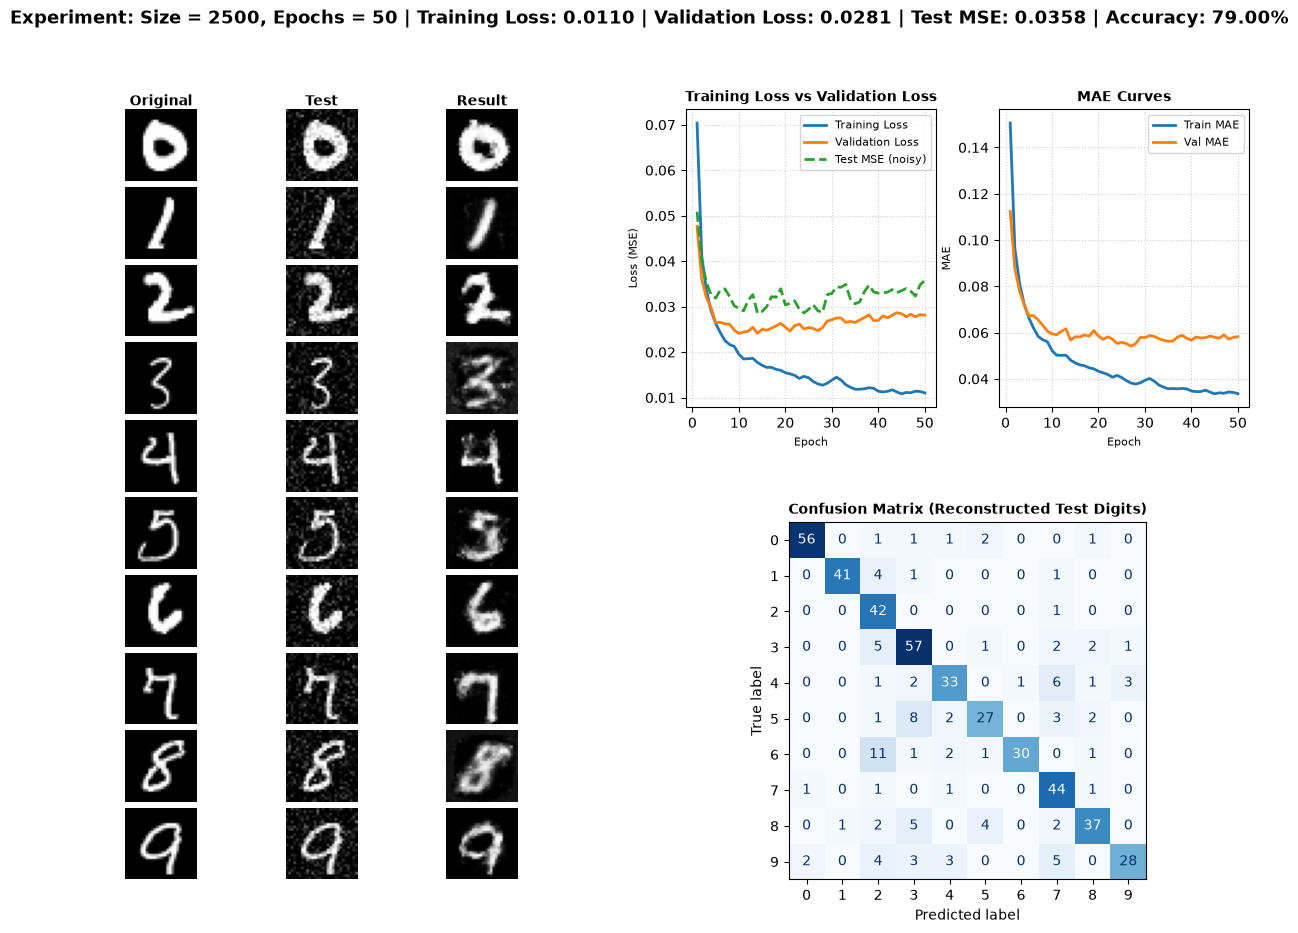

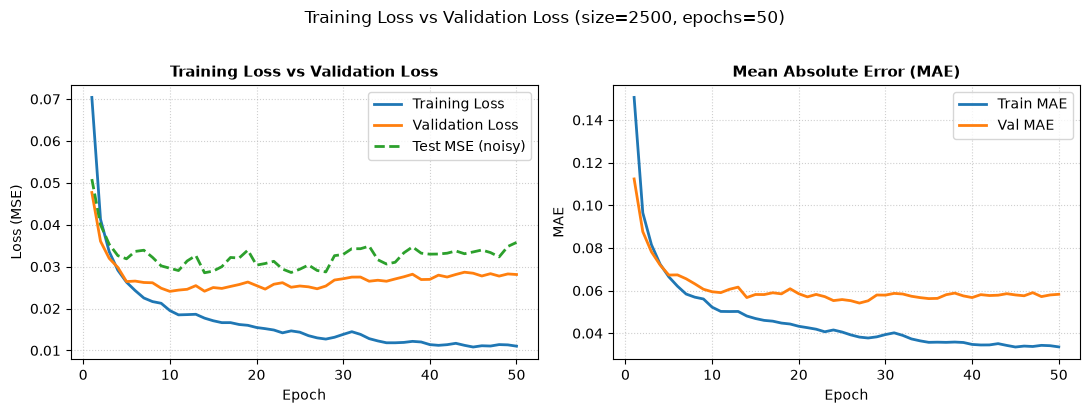

===== Size = 2500, Epochs = 100 =====
Train loss: 0.0103 | Val loss: 0.0317 | Train MSE: 0.0103 | Val MSE: 0.0317 | Train MAE: 0.0315 | Val MAE: 0.0618 | Test MSE: 0.0431 | Digit accuracy: 68.40%


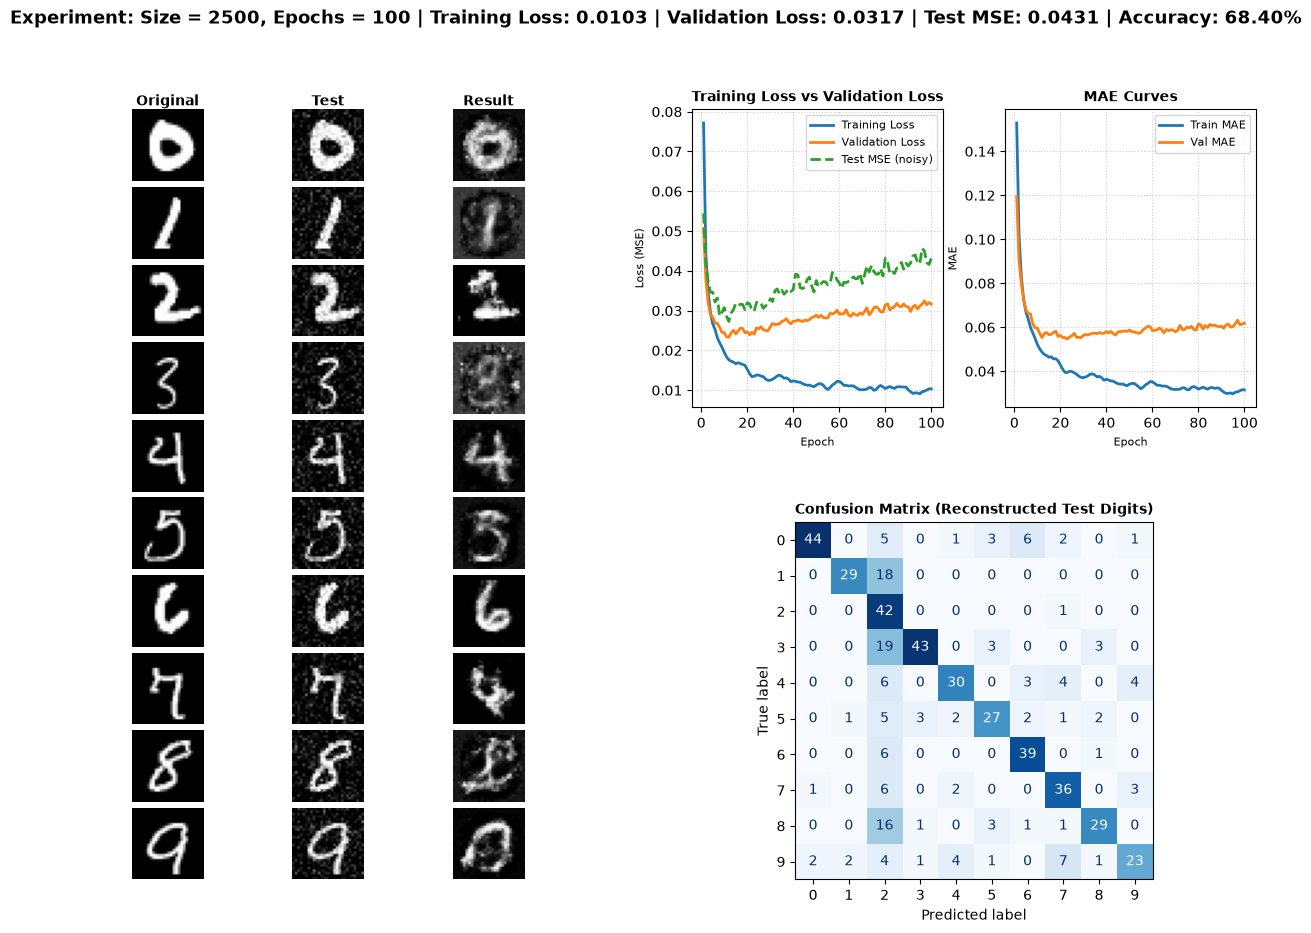

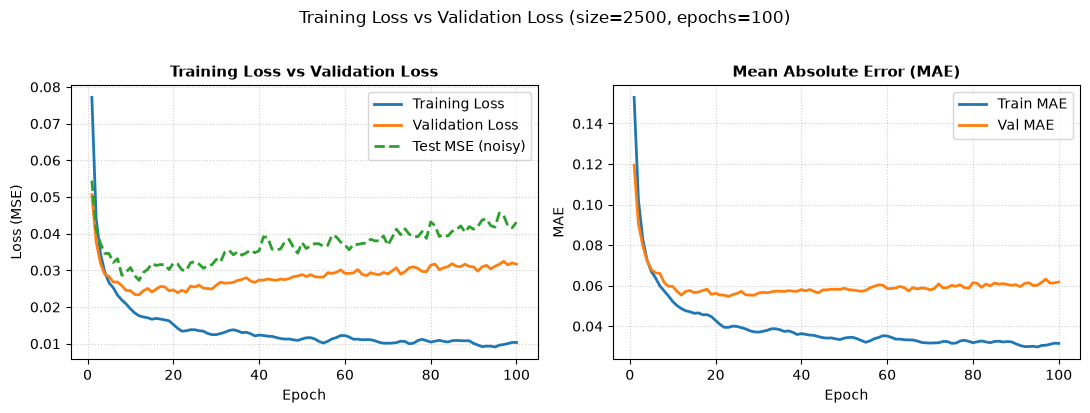

===== Size = 5000, Epochs = 50 =====
Train loss: 0.0137 | Val loss: 0.0223 | Train MSE: 0.0137 | Val MSE: 0.0223 | Train MAE: 0.0389 | Val MAE: 0.0509 | Test MSE: 0.0322 | Digit accuracy: 84.20%


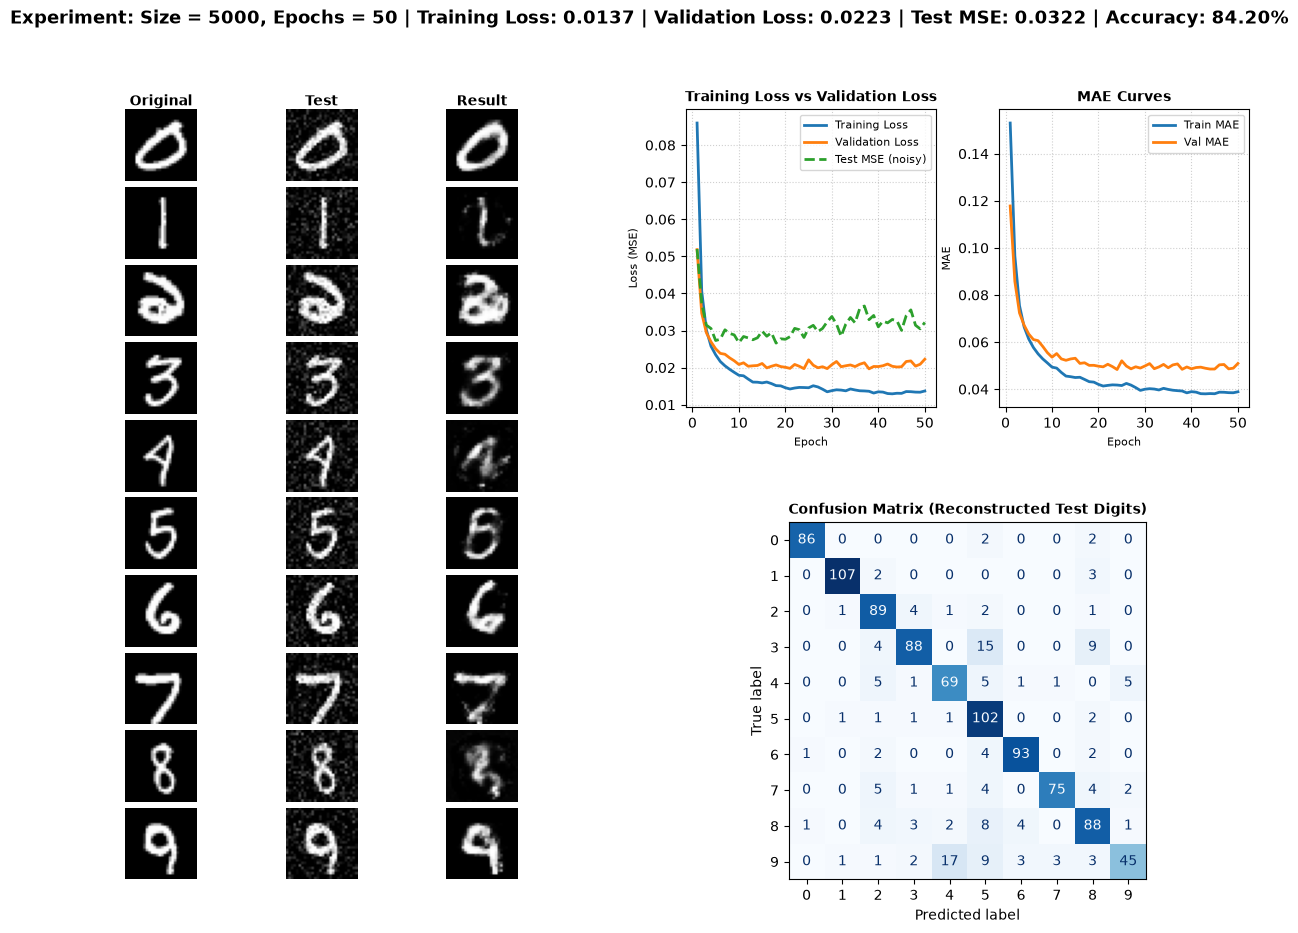

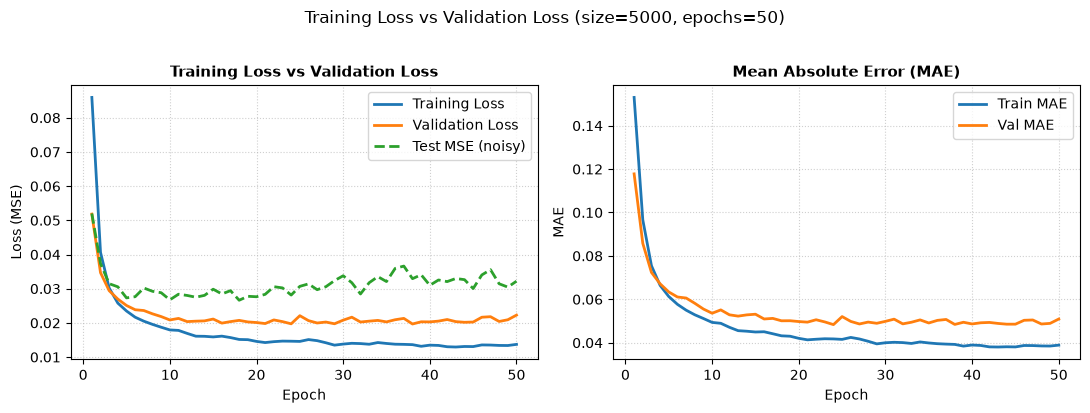

===== Size = 5000, Epochs = 100 =====
Train loss: 0.0127 | Val loss: 0.0245 | Train MSE: 0.0127 | Val MSE: 0.0245 | Train MAE: 0.0362 | Val MAE: 0.0524 | Test MSE: 0.0361 | Digit accuracy: 78.10%


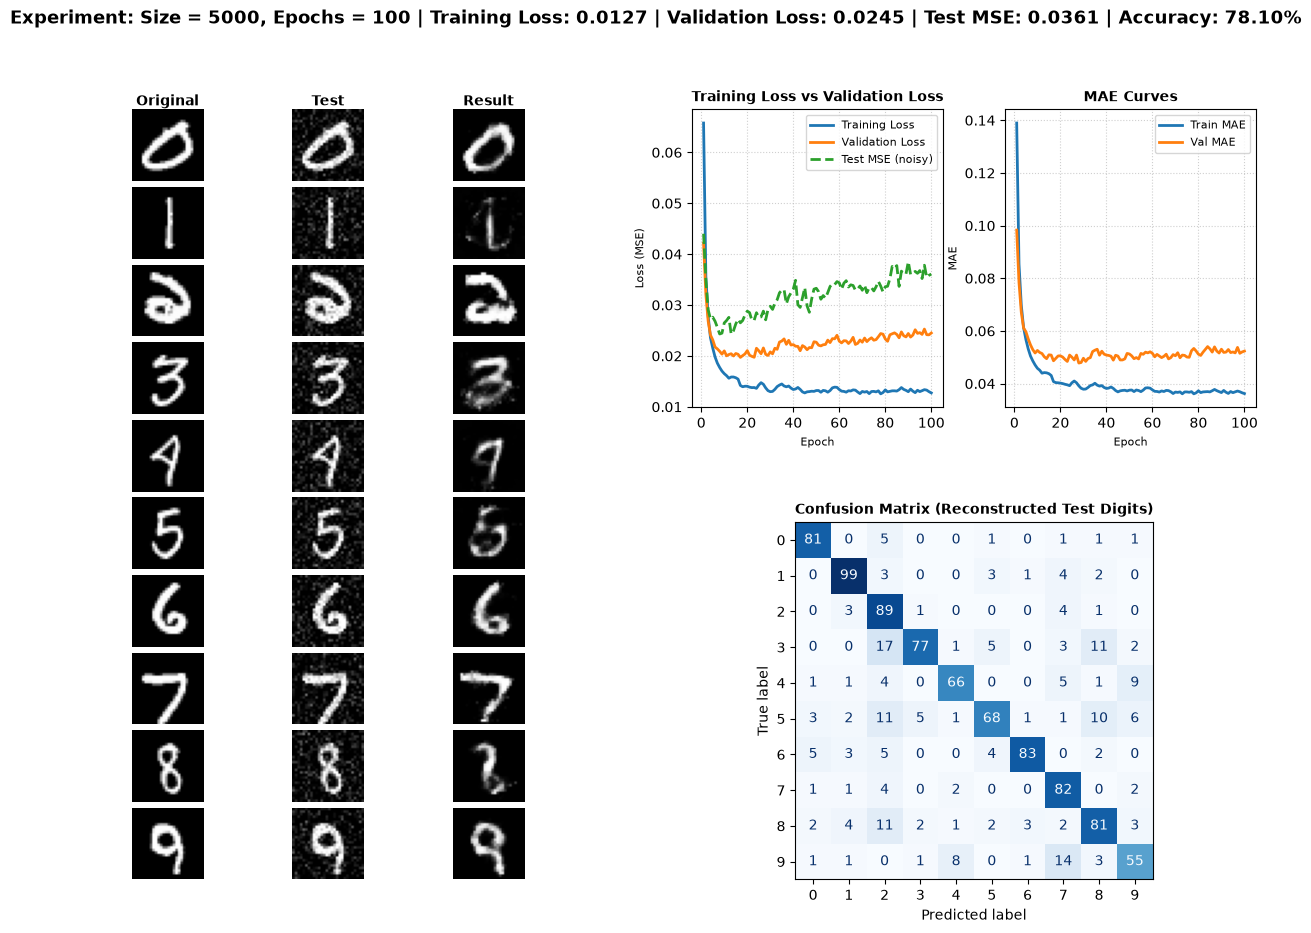

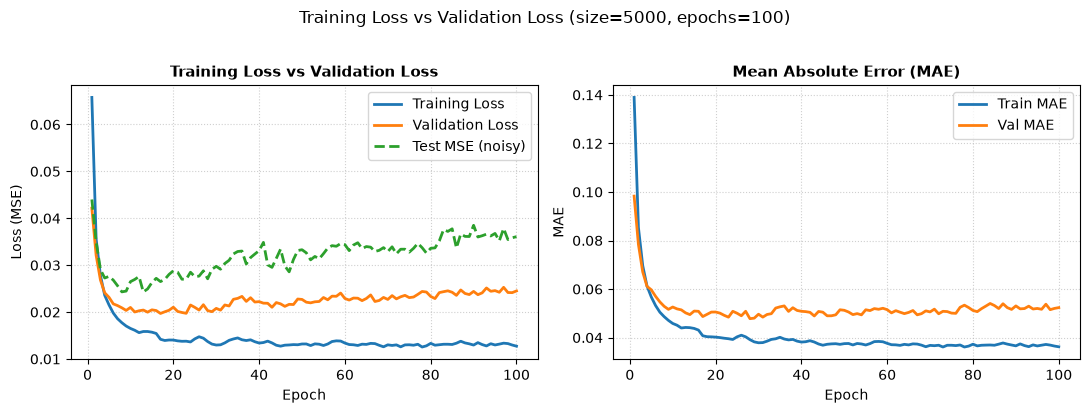

In [11]:
results = [run_experiment(size, epochs) for size in SIZES for epochs in EPOCHS]

## Summary table

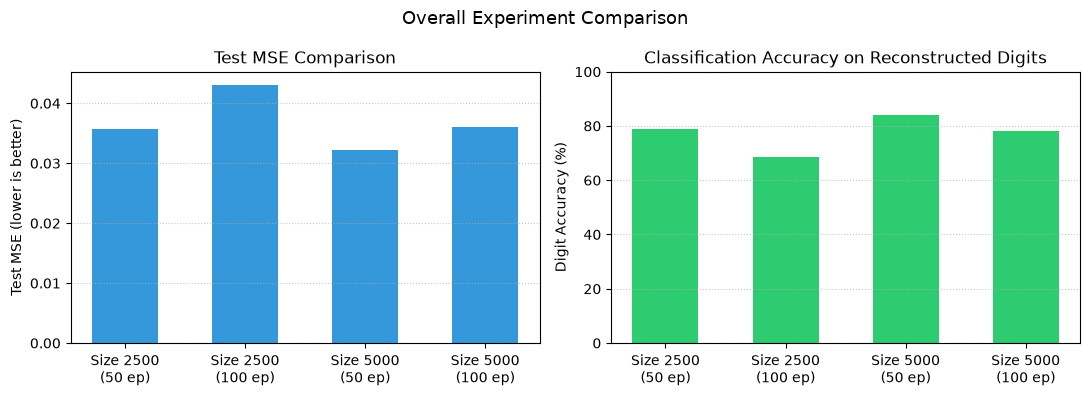

,Size,Epochs,Train Loss,Val Loss,Train MSE,Val MSE,Train MAE,Val MAE,Test MSE,Digit Accuracy
0,2500,50,0.0110,0.0281,0.0110,0.0281,0.0336,0.0583,0.0358,0.790
1,2500,100,0.0103,0.0317,0.0103,0.0317,0.0315,0.0618,0.0431,0.684
2,5000,50,0.0137,0.0223,0.0137,0.0223,0.0389,0.0509,0.0322,0.842
3,5000,100,0.0127,0.0245,0.0127,0.0245,0.0362,0.0524,0.0361,0.781


In [12]:
summary = pd.DataFrame(results).round(4)
summary.to_csv(f"{OUTPUT_DIR}/results.csv", index=False)

# Comparison graph across all configurations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
labels = [f"Size {r['Size']}\n({r['Epochs']} ep)" for r in results]
x_pos = np.arange(len(labels))

# Test MSE comparison
ax1.bar(x_pos, [r['Test MSE'] for r in results], color='#3498db', width=0.55)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Test MSE (lower is better)")
ax1.set_title("Test MSE Comparison")
ax1.grid(axis='y', linestyle=':', alpha=0.7)

# Digit Accuracy comparison
ax2.bar(x_pos, [r['Digit Accuracy'] * 100 for r in results], color='#2ecc71', width=0.55)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels)
ax2.set_ylabel("Digit Accuracy (%)")
ax2.set_title("Classification Accuracy on Reconstructed Digits")
ax2.set_ylim(0, 100)
ax2.grid(axis='y', linestyle=':', alpha=0.7)

fig.suptitle("Overall Experiment Comparison", fontsize=13)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/graph_summary_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

summary
